# Sensor Rankings
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary

In this notebook, we rank FloodNet sensors by the following statistics:

1. **Max Flood Depth**
   - 1.1 Top Flood Events by Maximum Flood Depth
   - 1.2 Top Sensors by Maximum Flood Depth
   - 1.3 Top Tidally Influenced Sensors by Maximum Flood Depth
   - 1.4 Top Non-Tidally Influenced Sensors by Maximum Flood Depth

---

2. **Frequency of Flood Events**
   - 2.1 Tidally Influenced Sensors by Normalized Event Frequency
   - 2.2 Non-Tidally Influenced Sensors by Normalized Event Frequency

---

3. **Flood Duration**
   - 3.1 Top Flood Events by Longest Duration
   - 3.2 Top Flood Events by Longest Duration (Minimum 12-Inch Depth)
   - 3.3 Top Flood Events by Duration Above 12 Inches
   - 3.4 Top Sensors by Longest Flood Duration
   - 3.5 Top Tidally Influenced Sensors by Longest Flood Duration
   - 3.6 Top Non-Tidally Influenced Sensors by Longest Flood Duration

---

4. **Average Flood Duration per Event**
   - 4.1 Top Sensors by Average Flood Duration
   - 4.2 Top Sensors by Average Flood Duration (Events Exceeding 12 Inches)

---

5. **Normalized Flood Duration by Deployment Length**
   - 5.1 Tidally Influenced Sensors by Average Flooded Hours per Month
   - 5.2 Non-Tidally Influenced Sensors by Average Flooded Hours per Month

---

6. **Bonus: Rate of Rise**
   - 6.1 Quickest Time to 12 Inches
   - 6.2 Quickest Time to 24 Inches
   - 6.3 Quickest Time to 12 Inches — Tidal vs. Non-Tidal

# Import Libraries

In [1]:
# libraries
import numpy as np
import pandas as pd
import polars as pl
import duckdb
from typing import Iterable, Optional
import ast
import json
from pathlib import Path
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
# print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "duckdb": duckdb.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
numpy      2.4.2
pandas     3.0.1
duckdb     1.4.4


In [3]:
# sanity check Manifest file
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
print(json.dumps(manifest, indent=2))

[
  {
    "dataset_id": "kb2e-tjy3",
    "name": "FloodNet: Sensor Deployment Metadata",
    "data_updated": "2026-05-15",
    "metadata_updated": null,
    "view_count": 407,
    "download_count": 287,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 433,
    "column_count": 16,
    "data_url": "https://data.cityofnewyork.us/resource/kb2e-tjy3.csv",
    "downloaded_at": "2026-05-17",
    "last_checked_at": "2026-05-17"
  },
  {
    "dataset_id": "aq7i-eu5q",
    "name": "FloodNet: Street Flooding Events Measured by FloodNet Sensors",
    "data_updated": "2026-05-15",
    "metadata_updated": null,
    "view_count": 1368,
    "download_count": 620,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 2256,
    "column_count": 13,
    "data_url":

Note: The manifest captures dataset metadata at the time of download. Since NYC Open Data datasets are updated periodically, results may differ over time. For the latest version, review the dataset page on NYC Open Data or rerun the data download notebook.

In [4]:
# list files in data directory
%ls data

Flood Events_Data Dictionary.xlsx
Floodnet_Open_Data_-_Data_Description_03.05.2026.pdf
boroughs.parquet
flood-events.csv
manifest.json
sensor-metadata.csv


To review how we downloaded these datasets from NYC Open Data, please refer to the previous notebook [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb).

# Load and Inspect Data
For a more robust approach to inspecting the data, please refer to notebook [01-load-inspect.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/01-load-inspect.ipynb).

In [5]:
# 1) read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata shape:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# 2) read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape

print("\nFlood Events shape:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata shape:
Number of rows: 433
Number of columns: 16

Flood Events shape:
Number of rows: 2,256
Number of columns: 13


# Join Sensor Metadata and Flood Events Datasets

In [6]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["sensor_id"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}\n")

# preview the first few rows
merged_df.head()

Number of rows of merged df: 2,256
Number of columns: 27
Events without matching sensor metadata: 0



sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


# Data Cleaning
Converting dates to local New York City datetime format.

In [7]:
merged_df = (
    merged_df
    # convert UTC to local time
    .with_columns(
        pl.col("flood_start_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_start_time_est"),

        pl.col("flood_end_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_end_time_est"),
    )
    # drop UTC time    
    .drop([
        "flood_start_time",
        "flood_end_time",
    ])
)

# preview local datetime
merged_df.select(["flood_start_time_est", "flood_end_time_est"]).head()

flood_start_time_est,flood_end_time_est
"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


# NYC Borough Boundaries
For mapping.

In [8]:
# read in NYC Boroughs geometries from NYC Open Data
path = "data/boroughs.parquet"
boro_gdf = gpd.read_parquet(path)

boro_gdf.head()

,borocode,boroname,shape_area,shape_leng,geometry
0,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,1,Manhattan,636631650.451,359537.866079,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
2,2,Bronx,1187199300.36,463147.071867,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."
3,3,Brooklyn,1934462607.43,726953.044632,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
4,4,Queens,3041419178.99,887905.076018,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."


shape of data: (433, 17)
EPSG:4326


<Axes: >

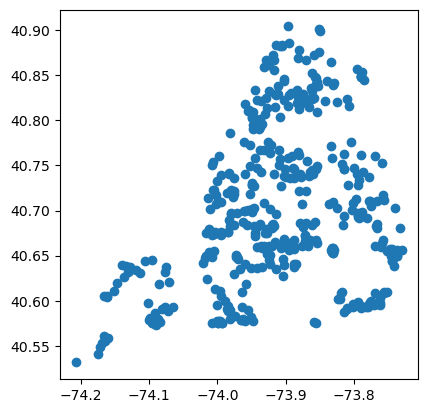

In [9]:
# generate geometry from x, y points
geometry = gpd.points_from_xy(
    metadata_df['longitude'],
    metadata_df['latitude']
)

# these coordinates are stored in 4326
crs = 4326

# create geodataframe
metadata_gdf = gpd.GeoDataFrame(
    metadata_df.to_pandas(),
    geometry=geometry,
    crs=crs
)

# sanity checks
print(f'shape of data: {metadata_gdf.shape}')
print(metadata_gdf.crs)

# sanity check, preview data
metadata_gdf.plot()

In [10]:
def plot_ranked_sensors(
    ranked_df,
    metadata_gdf,
    boro_gdf,
    value_col,
    title,
    label=None,
    join_col="sensor_id",
    figsize=(8, 8),
    cmap="viridis",
):
    """
    Plot ranked FloodNet sensors on a NYC borough map.

    Merges a ranked sensor DataFrame onto point geometries and renders
    each sensor as a choropleth dot scaled by value_col. All sensors
    in metadata_gdf are shown as light gray reference points; only those
    present in ranked_df are colored.

    Parameters
    ----------
    ranked_df : pl.DataFrame
        Polars DataFrame of ranked sensors. Must contain join_col and value_col.
    metadata_gdf : gpd.GeoDataFrame
        Point geometries for all deployed sensors. Must contain join_col.
    boro_gdf : gpd.GeoDataFrame
        NYC borough boundary polygons used as the base map.
    value_col : str
        Column name in ranked_df to use for color mapping.
    title : str
        Map title displayed above the plot.
    label : str, optional
        Colorbar label. If None, no label is added to the legend.
    join_col : str, optional
        Column name to join ranked_df onto metadata_gdf. Default is "sensor_id".
    figsize : tuple of float, optional
        Figure dimensions as (width, height) in inches. Default is (8, 8).
    cmap : str, optional
        Matplotlib colormap name. Default is "viridis".

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object.
    ax : matplotlib.axes.Axes
        The axes object.
    """
    # convert Polars to pandas
    ranked_pd = ranked_df.to_pandas()

    # merge ranked metrics onto geometry
    plot_gdf = (
        metadata_gdf
        .merge(
            ranked_pd,
            on=join_col,
            how="inner",
        )
        .sort_values(value_col)
    )

    legend_kwds = {
        "shrink": 0.70,
    }

    # optional legend label
    if label is not None:
        legend_kwds["label"] = label

    # create figure
    fig, ax = plt.subplots(figsize=figsize)

    # sensor plot
    plot_gdf.plot(
        column=value_col,
        ax=ax,
        legend=True,
        cmap=cmap,
        zorder=2,
        legend_kwds=legend_kwds,
    )

    # borough boundaries
    boro_gdf.plot(
        ax=ax,
        facecolor="None",
        linewidth=.5,
        edgecolor="gray",
        zorder=0,
    )

    metadata_gdf.plot(
        ax=ax,
        color="lightgray",
        alpha=0.35,
        zorder=1,
    )

    # labels
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()

    return fig, ax

# Sensor Rankings
FloodNet sensors continuously monitor street-level flood depths across New York City, generating a record of when, where, and how severely flooding occurs. This notebook ranks sensors and individual flood events across five dimensions: maximum flood depth, frequency of events, flood duration, average duration per event, and normalized flood burden by deployment length. Where relevant, sensors are separated into tidally influenced and non-tidally influenced groups, as the two populations reflect fundamentally different flooding mechanisms: coastal inundation driven by tidal cycles versus stormwater accumulation driven by rainfall and drainage capacity. Event counts and durations are normalized by deployment length to ensure sensors installed at different times remain directly comparable.

# 1) Max Flood Depth
## 1.1 Top 10 FloodNet Flood Events by Maximum Flood Depth
This table ranks individual **flood events** by maximum recorded flood depth. Because rankings are event-based, a single sensor location may appear multiple times if it recorded several high-depth flooding events.

In [11]:
# specify query in duckdb
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY max_depth_inches DESC
        ) AS rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
    FROM merged_df
    ORDER BY max_depth_inches DESC
    LIMIT 10
"""

# convert to Polars dataframe
ranked_df = duckdb.sql(sql).pl()

ranked_df

rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64
1,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,664.96
2,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2022-12-23 05:00:52 EST,2022-12-23 11:19:11 EST,"""Yes""","""Beach 84th Street""","""Queens""",38.19,378.31
3,"""BK-carroll-st-4th-av-0ery00""","""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,"""No""","""Carroll Street""","""Brooklyn""",35.94,129.18
4,"""BK-carroll-st-4th-av-0ery00""","""BK - Carroll St/4th Av""",2021-09-01 21:27:16 EDT,2021-09-01 23:11:26 EDT,"""No""","""Carroll Street""","""Brooklyn""",35.59,104.17
5,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-01-13 08:05:35 EST,2024-01-13 17:19:03 EST,"""Yes""","""Davenport Court""","""Queens""",34.69,553.46
6,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-04-03 12:04:19 EDT,2024-04-04 02:34:36 EDT,"""Yes""","""Ditmars Street""","""Bronx""",34.65,870.27
7,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2024-01-13 06:59:39 EST,2024-01-13 12:48:17 EST,"""Yes""","""Beach 84th Street""","""Queens""",32.52,348.63
8,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-12-23 05:12:13 EST,2022-12-23 11:34:35 EST,"""Yes""","""Russell Street""","""Queens""",31.77,382.38
9,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""",2022-12-23 05:10:48 EST,2022-12-23 11:04:16 EST,"""Yes""","""Russell Street""","""Queens""",31.34,353.47


We don't map flood events because one sensor can appear in **more than one ranking** in the top 10.

## 1.2 Top 10 FloodNet Sensors by Maximum Flood Depth
Table is ranked by depth **per unique sensor**. We take the **greatest depth per sensor**.

In [12]:
ranked_sensors = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
        ROW_NUMBER() OVER (
            PARTITION BY sensor_name
            ORDER BY max_depth_inches DESC
        ) AS event_rank_within_sensor
    FROM merged_df
""")

sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY max_depth_inches DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
    FROM ranked_sensors
    -- take highest event per sensor
    WHERE event_rank_within_sensor = 1
    ORDER BY max_depth_inches DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64
1,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,664.96
2,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2022-12-23 05:00:52 EST,2022-12-23 11:19:11 EST,"""Yes""","""Beach 84th Street""","""Queens""",38.19,378.31
3,"""BK-carroll-st-4th-av-0ery00""","""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,"""No""","""Carroll Street""","""Brooklyn""",35.94,129.18
4,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-04-03 12:04:19 EDT,2024-04-04 02:34:36 EDT,"""Yes""","""Ditmars Street""","""Bronx""",34.65,870.27
5,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-12-23 05:12:13 EST,2022-12-23 11:34:35 EST,"""Yes""","""Russell Street""","""Queens""",31.77,382.38
6,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""",2022-12-23 05:10:48 EST,2022-12-23 11:04:16 EST,"""Yes""","""Russell Street""","""Queens""",31.34,353.47
7,"""BK-9th-st-smith-st-0etvg0""","""BK - 9th St/Smith St""",2021-09-01 20:11:58 EDT,2021-09-02 00:42:32 EDT,"""No""","""9th Street""","""Brooklyn""",27.76,270.57
8,"""BK-wallabout-st-throop-ave-19q…","""BK - Wallabout St/Throop Ave""",2023-09-29 08:05:49 EDT,2023-09-29 11:03:49 EDT,"""No""","""Wallabout Street""","""Brooklyn""",25.08,178.0
9,"""BK-lee-ave-middleton-st-19qok0""","""BK - Lee Ave/Middleton St""",2023-09-29 08:07:18 EDT,2023-09-29 12:12:42 EDT,"""No""","""Lee Avenue""","""Brooklyn""",23.54,245.39


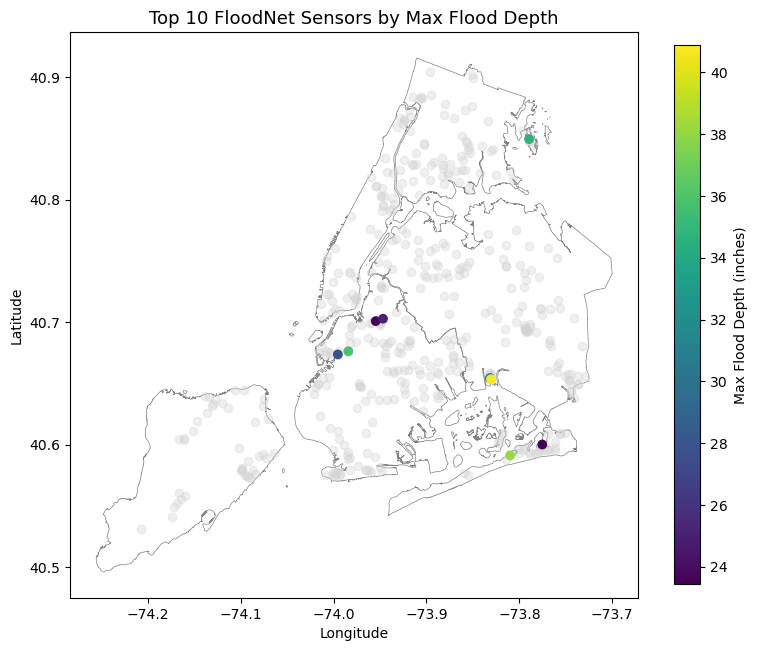

In [13]:
value_col = "max_depth_inches"
title = "Top 10 FloodNet Sensors by Max Flood Depth"
label = "Max Flood Depth (inches)"

# plot ranked sensors on  a map
fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 1.3 Top 10 Tidally Influenced Sensors by Maximum Flood Depth

In [14]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY max_depth_inches DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
    FROM ranked_sensors
    WHERE event_rank_within_sensor = 1
        -- rank only tidally influenced sensors
        AND tidally_influenced = 'Yes'
    ORDER BY max_depth_inches DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64
1,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,664.96
2,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2022-12-23 05:00:52 EST,2022-12-23 11:19:11 EST,"""Yes""","""Beach 84th Street""","""Queens""",38.19,378.31
3,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-04-03 12:04:19 EDT,2024-04-04 02:34:36 EDT,"""Yes""","""Ditmars Street""","""Bronx""",34.65,870.27
4,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-12-23 05:12:13 EST,2022-12-23 11:34:35 EST,"""Yes""","""Russell Street""","""Queens""",31.77,382.38
5,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""",2022-12-23 05:10:48 EST,2022-12-23 11:04:16 EST,"""Yes""","""Russell Street""","""Queens""",31.34,353.47
6,"""Q-beach-43rd-st-15qgw0""","""Q - Beach 43rd St""",2022-12-23 06:07:36 EST,2022-12-23 09:57:30 EST,"""Yes""","""Beach 43rd Street""","""Queens""",23.43,229.91
7,"""Q-102nd-st-160th-ave-1a5ng0""","""Q - 102nd St/160th Ave""",2024-01-13 07:46:45 EST,2024-01-13 12:18:31 EST,"""Yes""","""102nd Street""","""Queens""",21.69,271.78
8,"""Q-beach-72nd-st-almeda-ave-1a5…","""Q - Beach 72nd St/Almeda Ave""",2024-01-13 09:15:14 EST,2024-01-13 16:52:32 EST,"""Yes""","""Beach 72nd Street""","""Queens""",21.5,457.29
9,"""Q-beach-84th-st-beach-channel-…","""Q - Beach 84 St (2)""",2026-04-18 20:19:28 EDT,2026-04-19 00:35:27 EDT,"""Yes""","""Beach 84th Street""","""Queens""",20.67,255.98


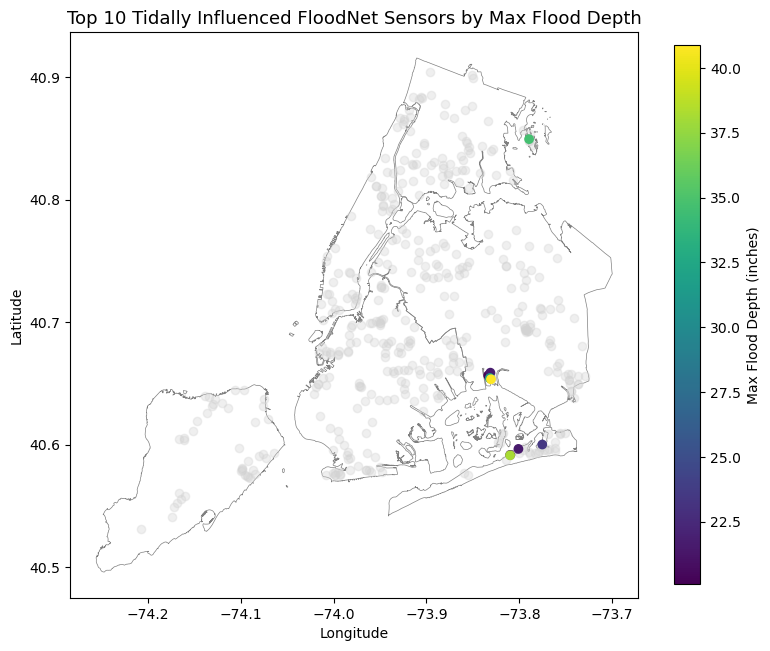

In [15]:
value_col = "max_depth_inches"
title = "Top 10 Tidally Influenced FloodNet Sensors by Max Flood Depth"
label = "Max Flood Depth (inches)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 1.4 Top 10 Non-Tidally Influenced Sensors by Maximum Flood Depth
Non-tidally influenced sensors are sometimes evaluated independently, since their flood depths are driven primarily by rainfall and drainage conditions rather than tidal cycles, resulting in different flooding dynamics than tidally influenced sensors. This is visible by the frequency of flooding events, where tidally influenced sensors dominate the frequency of events.

In [16]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY max_depth_inches DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins
    FROM ranked_sensors
    WHERE event_rank_within_sensor = 1
        -- rank non-tidal sennsors
        AND tidally_influenced = 'No'
    ORDER BY max_depth_inches DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64
1,"""BK-carroll-st-4th-av-0ery00""","""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,"""No""","""Carroll Street""","""Brooklyn""",35.94,129.18
2,"""BK-9th-st-smith-st-0etvg0""","""BK - 9th St/Smith St""",2021-09-01 20:11:58 EDT,2021-09-02 00:42:32 EDT,"""No""","""9th Street""","""Brooklyn""",27.76,270.57
3,"""BK-wallabout-st-throop-ave-19q…","""BK - Wallabout St/Throop Ave""",2023-09-29 08:05:49 EDT,2023-09-29 11:03:49 EDT,"""No""","""Wallabout Street""","""Brooklyn""",25.08,178.0
4,"""BK-lee-ave-middleton-st-19qok0""","""BK - Lee Ave/Middleton St""",2023-09-29 08:07:18 EDT,2023-09-29 12:12:42 EDT,"""No""","""Lee Avenue""","""Brooklyn""",23.54,245.39
5,"""Q-204th-st-100th-ave-2msf80""","""Q - 204th St/ 100th Ave""",2025-10-30 16:04:44 EDT,2025-10-30 16:47:45 EDT,"""No""","""204th Street""","""Queens""",23.35,43.02
6,"""BK-kingston-ave-rutland-rd-1dn…","""BK - Kingston Ave/Rutland Rd""",2025-10-30 15:02:07 EDT,2025-10-30 17:26:22 EDT,"""No""","""Kingston Avenue""","""Brooklyn""",23.35,144.24
7,"""BK-knickerbocker-ave-hart-st-1…","""BK - Knickerbocker Ave/ Hart S…",2025-10-30 15:09:13 EDT,2025-10-30 17:15:42 EDT,"""No""","""Knickerbocker Avenue""","""Brooklyn""",22.76,126.48
8,"""Q-peck-ave-153rd-st-1lmug0""","""Q - Peck Ave/153rd st""",2025-10-30 15:54:42 EDT,2025-10-30 17:40:42 EDT,"""No""","""153rd Street""","""Queens""",22.64,106.0
9,"""Q-56th-ave-springfield-blvd-1z…","""Q - 56th Ave/ Springfield Blvd""",2025-10-30 15:51:23 EDT,2025-10-30 19:30:22 EDT,"""No""","""56th Avenue""","""Queens""",21.93,218.98


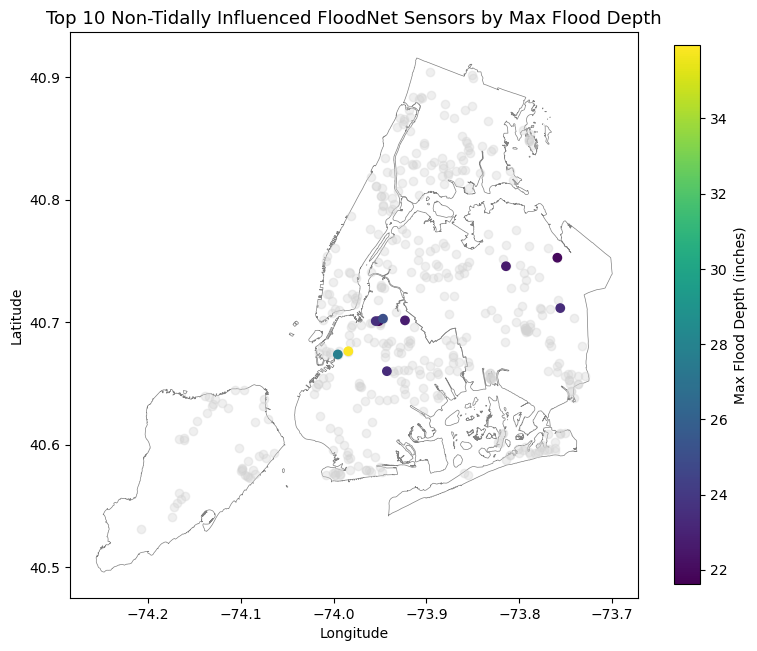

In [17]:
value_col = "max_depth_inches"
title = "Top 10 Non-Tidally Influenced FloodNet Sensors by Max Flood Depth"
label = "Max Flood Depth (inches)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

# 2) Frequency of Flood Events
Counts are normalized by the number of days each sensor was deployed. As sensors were installed in different years, **raw event counts are not directly comparable without normalization**.

## Normalize Event Counts

In [18]:
days_deployed = duckdb.sql("""
    SELECT
        sensor_id,
        date_diff(
            'day',
            date_installed,
            current_date()
        ) AS days_deployed
    FROM metadata_df
""")

flood_events = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        MAX(max_depth_inches) AS max_depth_inches,
        COUNT(*) AS flood_events
    FROM merged_df
    GROUP BY ALL
""")

sql = """
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        days_deployed,
        max_depth_inches,
        flood_events,
        ROUND(flood_events /  days_deployed * (365 / 12.0), 2) AS flood_events_per_month
    FROM flood_events
    JOIN days_deployed USING (sensor_id)
    ORDER BY flood_events_per_month DESC
"""

events_per_month_df = duckdb.sql(sql).pl()

# preview aggregated table with days deployed attribute
events_per_month_df.head()

sensor_id,sensor_name,street_name,borough,tidally_influenced,days_deployed,max_depth_inches,flood_events,flood_events_per_month
str,str,str,str,str,i64,f64,i64,f64
"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""","""Ditmars Street""","""Bronx""","""Yes""",948,34.65,309,9.91
"""Q-beach-84th-st-beach-channel-…","""Q - Beach 84 St (2)""","""Beach 84th Street""","""Queens""","""Yes""",200,20.67,52,7.91
"""Q-beach-84-st-0me680""","""Q - Beach 84 St""","""Beach 84th Street""","""Queens""","""Yes""",1619,38.19,397,7.46
"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",584,19.76,91,4.74
"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",584,17.68,57,2.97


## 2.1 Normalized Top 10 Number of Events by Tidally Influenced Sensors

In [19]:
sql = """
    SELECT 
        ROW_NUMBER() OVER (
            ORDER BY flood_events_per_month DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        days_deployed,
        max_depth_inches,
        flood_events,
        flood_events_per_month
    FROM events_per_month_df
    WHERE tidally_influenced = 'Yes'
    ORDER BY flood_events_per_month DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,days_deployed,max_depth_inches,flood_events,flood_events_per_month
i64,str,str,str,str,str,i64,f64,i64,f64
1,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""","""Ditmars Street""","""Bronx""","""Yes""",948,34.65,309,9.91
2,"""Q-beach-84th-st-beach-channel-…","""Q - Beach 84 St (2)""","""Beach 84th Street""","""Queens""","""Yes""",200,20.67,52,7.91
3,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""","""Beach 84th Street""","""Queens""","""Yes""",1619,38.19,397,7.46
4,"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",584,19.76,91,4.74
5,"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",584,17.68,57,2.97
6,"""Q-brookville-blvd-149th-ave-3-…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",584,13.94,53,2.76
7,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""","""Russell Street""","""Queens""","""Yes""",1899,31.34,133,2.13
8,"""Q-beach-35-st-beach-channel-dr…","""Q - Beach 35 St/Beach Channel …","""Beach 35th Street""","""Queens""","""Yes""",880,11.77,61,2.11
9,"""Q-102nd-st-160th-ave-1a5ng0""","""Q - 102nd St/160th Ave""","""102nd Street""","""Queens""","""Yes""",1157,21.69,72,1.89


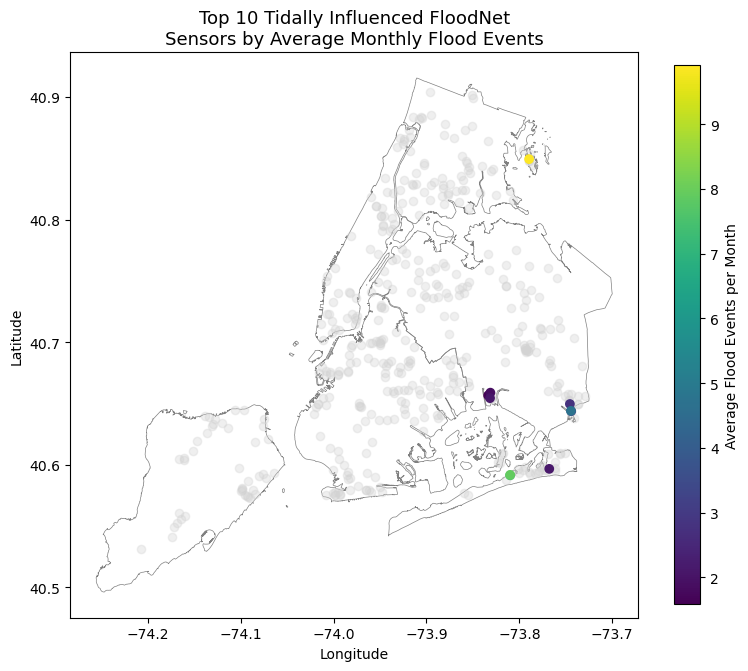

In [20]:
value_col = "flood_events_per_month"
title = "Top 10 Tidally Influenced FloodNet\nSensors by Average Monthly Flood Events"
label = "Average Flood Events per Month"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 2.2 Normalized Top 10 Number of Events by Non-Tidally Influenced Sensors

In [21]:
sql = """
    SELECT 
        ROW_NUMBER() OVER (
            ORDER BY flood_events_per_month DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        days_deployed,
        max_depth_inches,
        flood_events,
        flood_events_per_month
    FROM events_per_month_df
    WHERE tidally_influenced = 'No'
    ORDER BY flood_events_per_month DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()
ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,days_deployed,max_depth_inches,flood_events,flood_events_per_month
i64,str,str,str,str,str,i64,f64,i64,f64
1,"""Q-beach-59th-st-beach-channel-…","""Q - Beach Chn Dr/ Beach 59th S…","""Beach Channel Drive""","""Queens""","""No""",44,4.72,3,2.07
2,"""BX-w-234th-st-tibbett-ave-2cak…","""BX - Tibbett Ave/W 234th St""","""Tibbett Avenue""","""Bronx""","""No""",416,1.5,19,1.39
3,"""Q-160th-ave-101st-st-2vfj80""","""Q - 101st St/160th Ave""","""101st Street""","""Queens""","""No""",44,2.68,2,1.38
4,"""BK-e-92nd-st-avenue-j-2nick0""","""BK - E92nd St/ Ave J""","""East 92nd Street""","""Brooklyn""","""No""",198,1.34,7,1.08
5,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""","""Webster Avenue""","""Bronx""","""No""",633,11.54,19,0.91
8,"""BK-vermont-st-linden-blvd-2tzq…","""BK - Linden Blvd/Vermont St""","""Linden Boulevard""","""Brooklyn""","""No""",72,0.91,2,0.84
6,"""BK-livonia-ave-georgia-ave-2tz…","""BK - Georgia Ave/ Livonia Ave""","""Georgia Avenue""","""Brooklyn""","""No""",72,0.94,2,0.84
7,"""BK-lott-ave-thatford-ave-2tzql…","""BK - Lott Ave/Thatford Ave""","""Lott Avenue""","""Brooklyn""","""No""",72,0.71,2,0.84
9,"""Q-beach-90th-st-rockaway-freew…","""Q - Beach 90th St/ Rockaway Fw…","""Beach 90th Street""","""Queens""","""No""",44,5.71,1,0.69


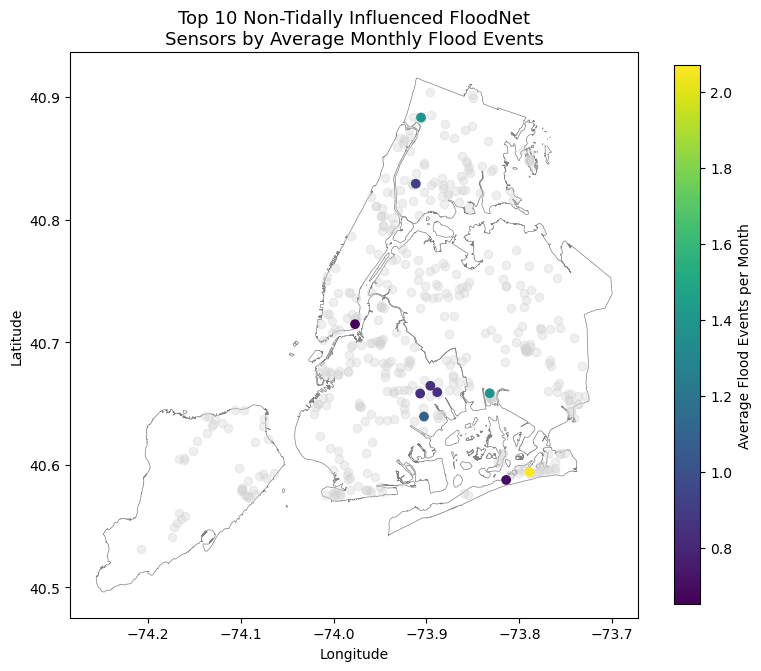

In [22]:
value_col = "flood_events_per_month"
title = "Top 10 Non-Tidally Influenced FloodNet\nSensors by Average Monthly Flood Events"
label = "Average Flood Events per Month"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

# 3) Flood Duration

## 3.1 Top 10 FloodNet Flood Events by Longest Flood Duration

In [23]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_mins DESC
        ) AS rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
    FROM merged_df
    ORDER BY duration_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64
1,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""",2026-03-18 14:36:17 EDT,2026-03-21 18:19:12 EDT,"""No""","""Webster Avenue""","""Bronx""",7.8,4542.91,0.0
2,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2025-02-16 01:31:03 EST,2025-02-18 11:37:03 EST,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",3.31,3485.99,0.0
3,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2024-04-02 14:36:42 EDT,2024-04-04 14:42:50 EDT,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",3.98,2886.13,0.0
4,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""",2024-04-02 15:17:22 EDT,2024-04-04 12:16:11 EDT,"""Yes""","""Minnieford Avenue""","""Bronx""",2.52,2698.82,0.0
5,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2023-10-20 16:22:29 EDT,2023-10-22 12:10:08 EDT,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",3.46,2627.65,0.0
6,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2023-09-29 03:53:34 EDT,2023-09-30 15:59:42 EDT,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",5.59,2166.14,0.0
7,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2025-05-22 05:44:09 EDT,2025-05-23 14:10:54 EDT,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",1.97,1946.75,0.0
8,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-10-03 13:48:55 EDT,2022-10-04 20:17:31 EDT,"""Yes""","""Russell Street""","""Queens""",7.48,1828.59,0.0
9,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""",2024-03-06 15:56:28 EST,2024-03-07 20:18:55 EST,"""Yes""","""Minnieford Avenue""","""Bronx""",2.05,1702.46,0.0


## 3.2 Top 10 FloodNet Flood Events by Longest Flood Duration Where Maximum Flood Depth Reached at Least 12 Inches

In [24]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_mins DESC
        ) AS rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
    FROM merged_df
    WHERE max_depth_inches >= 12
    ORDER BY duration_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64
1,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2022-01-01 18:14:07 EST,2022-01-02 11:06:22 EST,"""Yes""","""Beach 84th Street""","""Queens""",22.44,1012.26,141.89
2,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2023-09-29 06:51:28 EDT,2023-09-29 23:12:18 EDT,"""Yes""","""Beach 84th Street""","""Queens""",16.65,980.84,115.15
3,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-04-03 12:04:19 EDT,2024-04-04 02:34:36 EDT,"""Yes""","""Ditmars Street""","""Bronx""",34.65,870.27,413.82
4,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,664.96,516.27
5,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2023-09-29 07:11:07 EDT,2023-09-29 17:46:33 EDT,"""Yes""","""Davenport Court""","""Queens""",15.43,635.44,445.59
6,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-08-06 17:13:03 EDT,2024-08-07 02:55:34 EDT,"""Yes""","""Ditmars Street""","""Bronx""",15.75,582.53,314.1
7,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-01-13 08:05:35 EST,2024-01-13 17:19:03 EST,"""Yes""","""Davenport Court""","""Queens""",34.69,553.46,393.28
8,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-03-09 18:52:22 EST,2024-03-10 05:00:51 EDT,"""Yes""","""Davenport Court""","""Queens""",20.71,548.48,386.02
9,"""Q-beach-72nd-st-almeda-ave-1a5…","""Q - Beach 72nd St/Almeda Ave""",2023-09-29 10:30:26 EDT,2023-09-29 19:35:04 EDT,"""Yes""","""Beach 72nd Street""","""Queens""",12.24,544.65,23.36


## 3.3 Top 10 FloodNet Flood Events by Duration Above 12 Inches

In [25]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_above_12_inches_mins DESC
        ) AS rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
    FROM merged_df
    ORDER BY duration_above_12_inches_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64
1,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,664.96,516.27
2,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2023-09-29 07:11:07 EDT,2023-09-29 17:46:33 EDT,"""Yes""","""Davenport Court""","""Queens""",15.43,635.44,445.59
3,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-04-03 12:04:19 EDT,2024-04-04 02:34:36 EDT,"""Yes""","""Ditmars Street""","""Bronx""",34.65,870.27,413.82
4,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-01-13 08:05:35 EST,2024-01-13 17:19:03 EST,"""Yes""","""Davenport Court""","""Queens""",34.69,553.46,393.28
5,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-03-09 18:52:22 EST,2024-03-10 05:00:51 EDT,"""Yes""","""Davenport Court""","""Queens""",20.71,548.48,386.02
6,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-04-04 02:53:17 EDT,2024-04-04 11:50:59 EDT,"""Yes""","""Davenport Court""","""Queens""",20.83,537.7,378.5
7,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-03-10 07:44:49 EDT,2024-03-10 15:32:08 EDT,"""Yes""","""Davenport Court""","""Queens""",26.06,467.32,325.8
8,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-08-06 17:13:03 EDT,2024-08-07 02:55:34 EDT,"""Yes""","""Ditmars Street""","""Bronx""",15.75,582.53,314.1
9,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2024-01-10 05:39:07 EST,2024-01-10 13:13:49 EST,"""Yes""","""Davenport Court""","""Queens""",23.94,454.7,293.19


## 3.4 Top 10 FloodNet Sensors by Longest Flood Duration
This table ranks unique FloodNet sensors by the longest recorded flood duration. For each sensor, only the **single longest qualifying flood event is included**.

In [26]:
ranked_sensors = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
        ROW_NUMBER() OVER (
            PARTITION BY sensor_name
            ORDER BY duration_mins DESC
        ) AS event_rank_within_sensor
    FROM merged_df
""")

sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_mins DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        ROUND(duration_mins / 60.0, 2) AS duration_hrs,
        duration_mins,
        duration_above_12_inches_mins
    FROM ranked_sensors
    WHERE event_rank_within_sensor = 1
    ORDER BY duration_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_hrs,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64,f64
1,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""",2026-03-18 14:36:17 EDT,2026-03-21 18:19:12 EDT,"""No""","""Webster Avenue""","""Bronx""",7.8,75.72,4542.91,0.0
2,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2025-02-16 01:31:03 EST,2025-02-18 11:37:03 EST,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",3.31,58.1,3485.99,0.0
3,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""",2024-04-02 15:17:22 EDT,2024-04-04 12:16:11 EDT,"""Yes""","""Minnieford Avenue""","""Bronx""",2.52,44.98,2698.82,0.0
4,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-10-03 13:48:55 EDT,2022-10-04 20:17:31 EDT,"""Yes""","""Russell Street""","""Queens""",7.48,30.48,1828.59,0.0
5,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2025-10-13 12:48:33 EDT,2025-10-14 13:26:29 EDT,"""Yes""","""Beach 84th Street""","""Queens""",3.7,24.63,1477.93,0.0
6,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-03-23 00:41:19 EDT,2024-03-24 00:15:43 EDT,"""Yes""","""Ditmars Street""","""Bronx""",11.1,23.57,1414.4,0.0
7,"""BK-hoyt-st-5th-st-007sk0""","""BK - Hoyt St/5th St""",2024-03-06 16:10:53 EST,2024-03-07 10:38:14 EST,"""No""","""Hoyt Street""","""Brooklyn""",4.25,18.46,1107.36,0.0
8,"""Q-204th-st-100th-ave-2msf80""","""Q - 204th St/ 100th Ave""",2026-03-16 00:29:46 EDT,2026-03-16 17:14:46 EDT,"""No""","""204th Street""","""Queens""",1.65,16.75,1005.0,0.0
9,"""Q-davenport-ct-2-07znk0""","""Q - Davenport Ct 2""",2021-05-28 22:29:53 EDT,2021-05-29 13:27:13 EDT,"""Yes""","""Davenport Court""","""Queens""",10.98,14.96,897.34,0.0


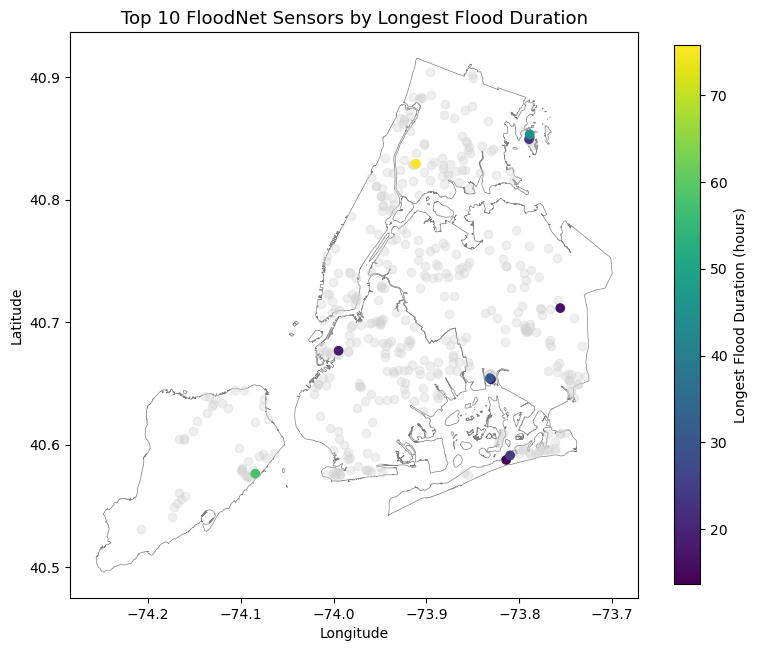

In [27]:
value_col = "duration_hrs"
title = "Top 10 FloodNet Sensors by Longest Flood Duration"
label = "Longest Flood Duration (hours)"


fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 3.5 Top 10 Tidally Influenced Sensors by Longest Flood Duration

In [28]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_mins DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        ROUND(duration_mins / 60.0, 2) AS duration_hrs,
        duration_mins,
        duration_above_12_inches_mins,
    FROM ranked_sensors
    WHERE event_rank_within_sensor = 1
        AND tidally_influenced = 'Yes'
    ORDER BY duration_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_hrs,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64,f64
1,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""",2025-02-16 01:31:03 EST,2025-02-18 11:37:03 EST,"""Yes""","""Quincy Avenue, Comanche Avenue""","""Staten Island""",3.31,58.1,3485.99,0.0
2,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""",2024-04-02 15:17:22 EDT,2024-04-04 12:16:11 EDT,"""Yes""","""Minnieford Avenue""","""Bronx""",2.52,44.98,2698.82,0.0
3,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""",2022-10-03 13:48:55 EDT,2022-10-04 20:17:31 EDT,"""Yes""","""Russell Street""","""Queens""",7.48,30.48,1828.59,0.0
4,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""",2025-10-13 12:48:33 EDT,2025-10-14 13:26:29 EDT,"""Yes""","""Beach 84th Street""","""Queens""",3.7,24.63,1477.93,0.0
5,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""",2024-03-23 00:41:19 EDT,2024-03-24 00:15:43 EDT,"""Yes""","""Ditmars Street""","""Bronx""",11.1,23.57,1414.4,0.0
6,"""Q-davenport-ct-2-07znk0""","""Q - Davenport Ct 2""",2021-05-28 22:29:53 EDT,2021-05-29 13:27:13 EDT,"""Yes""","""Davenport Court""","""Queens""",10.98,14.96,897.34,0.0
7,"""Q-brookville-blvd-149th-ave-3-…","""Q - Brookville Blvd/ Snake Rd …",2025-10-13 22:59:59 EDT,2025-10-14 10:15:57 EDT,"""Yes""","""Brookville Boulevard""","""Queens""",3.39,11.27,675.97,0.0
8,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,"""Yes""","""Davenport Court""","""Queens""",40.87,11.08,664.96,516.27
9,"""SI-baden-pl-mapleton-ave-1dejs…","""SI - Baden Pl/ Mapleton Ave""",2023-09-29 07:21:47 EDT,2023-09-29 17:26:30 EDT,"""Yes""","""Mapleton Avenue""","""Staten Island""",5.75,10.08,604.71,0.0


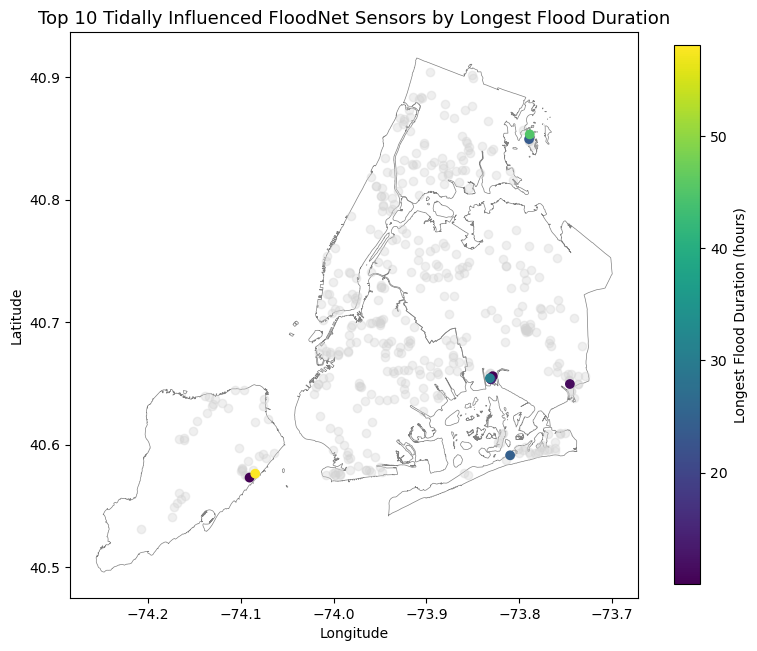

In [29]:
value_col = "duration_hrs"
title = "Top 10 Tidally Influenced FloodNet Sensors by Longest Flood Duration"
label = "Longest Flood Duration (hours)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 3.6 Top Non-Tidally Influenced Sensors by Longest Flood Duration

In [30]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY duration_mins DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        flood_start_time_est,
        flood_end_time_est,
        tidally_influenced,
        street_name,
        borough,
        max_depth_inches,
        ROUND(duration_mins / 60.0, 2) AS duration_hrs,
        duration_mins,
        duration_above_12_inches_mins,
    FROM ranked_sensors
    WHERE event_rank_within_sensor = 1
        AND tidally_influenced = 'No'
    ORDER BY duration_mins DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,flood_start_time_est,flood_end_time_est,tidally_influenced,street_name,borough,max_depth_inches,duration_hrs,duration_mins,duration_above_12_inches_mins
i64,str,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",str,str,str,f64,f64,f64,f64
1,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""",2026-03-18 14:36:17 EDT,2026-03-21 18:19:12 EDT,"""No""","""Webster Avenue""","""Bronx""",7.8,75.72,4542.91,0.0
2,"""BK-hoyt-st-5th-st-007sk0""","""BK - Hoyt St/5th St""",2024-03-06 16:10:53 EST,2024-03-07 10:38:14 EST,"""No""","""Hoyt Street""","""Brooklyn""",4.25,18.46,1107.36,0.0
3,"""Q-204th-st-100th-ave-2msf80""","""Q - 204th St/ 100th Ave""",2026-03-16 00:29:46 EDT,2026-03-16 17:14:46 EDT,"""No""","""204th Street""","""Queens""",1.65,16.75,1005.0,0.0
4,"""Q-beach-90th-st-rockaway-freew…","""Q - Beach 90th St/ Rockaway Fw…",2026-04-18 21:30:30 EDT,2026-04-19 11:09:13 EDT,"""No""","""Beach 90th Street""","""Queens""",5.71,13.65,818.71,0.0
5,"""BX-1st-st-avenue-a-1zby90""","""BX - 1st St/Avenue A""",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT,"""No""","""Avenue A""","""Bronx""",6.18,12.64,758.24,0.0
6,"""BX-hobart-ave-coddington-ave-2…","""BX - Hobart Ave/ Coddington Av…",2026-03-05 07:30:25 EST,2026-03-05 19:59:23 EST,"""No""","""Hobart Avenue""","""Bronx""",2.44,12.48,748.97,0.0
7,"""BX-w-234th-st-tibbett-ave-2cak…","""BX - Tibbett Ave/W 234th St""",2026-03-05 19:47:22 EST,2026-03-06 07:51:21 EST,"""No""","""Tibbett Avenue""","""Bronx""",1.18,12.07,723.98,0.0
8,"""Q-51st-ave-jacobus-st-20q7k0""","""Q - 51st Ave/Jacobus St""",2026-03-05 20:00:05 EST,2026-03-06 06:32:04 EST,"""No""","""51st Avenue""","""Queens""",3.15,10.53,631.98,0.0
9,"""Q-155th-ave-79th-st-215zzc""","""Q - 155th Ave/79th St""",2026-04-25 15:46:58 EDT,2026-04-26 02:10:56 EDT,"""No""","""79th Street""","""Queens""",2.8,10.4,623.97,0.0


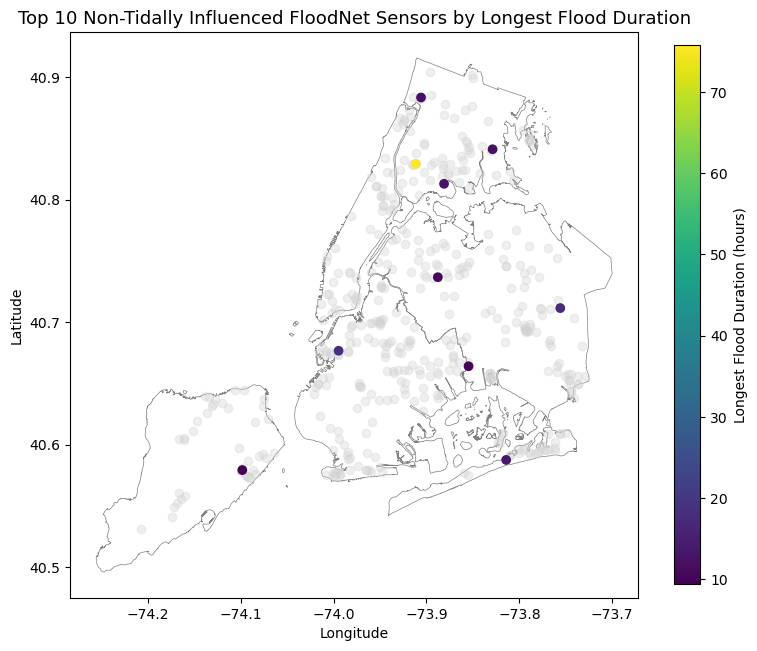

In [31]:
value_col = "duration_hrs"
title = "Top 10 Non-Tidally Influenced FloodNet Sensors by Longest Flood Duration"
label = "Longest Flood Duration (hours)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

# 4) Average Flood Duration per Event
Total flood duration alone favors sensors with more events. Dividing by event count isolates the typical duration of a single flood, making sensors with few long events directly comparable to those with many short ones.

## 4.1 Top 10 Sensors by Average Flood Duration

In [32]:
sensor_flood_summary = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        MAX(max_depth_inches) AS max_depth_inches,
        COUNT(sensor_id) AS flood_events,
        SUM(duration_mins) AS duration_mins,
        ROUND(SUM(duration_mins) / COUNT(sensor_id) / 60.0, 2) AS average_duration_hrs
    FROM merged_df
    GROUP BY ALL
""")

sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY average_duration_hrs DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        max_depth_inches,
        flood_events,
        duration_mins,
        average_duration_hrs
    FROM sensor_flood_summary
    ORDER BY average_duration_hrs DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,max_depth_inches,flood_events,duration_mins,average_duration_hrs
i64,str,str,str,str,str,f64,i64,f64,f64
1,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""","""Minnieford Avenue""","""Bronx""","""Yes""",2.52,9,11437.37,21.18
2,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""","""Quincy Avenue, Comanche Avenue""","""Staten Island""","""Yes""",5.59,38,33934.3,14.88
3,"""Q-beach-90th-st-rockaway-freew…","""Q - Beach 90th St/ Rockaway Fw…","""Beach 90th Street""","""Queens""","""No""",5.71,1,818.71,13.65
4,"""BX-hobart-ave-coddington-ave-2…","""BX - Hobart Ave/ Coddington Av…","""Hobart Avenue""","""Bronx""","""No""",2.44,1,748.97,12.48
5,"""Q-204th-st-100th-ave-2msf80""","""Q - 204th St/ 100th Ave""","""204th Street""","""Queens""","""No""",23.35,2,1048.02,8.73
6,"""BX-1st-st-avenue-a-1zby90""","""BX - 1st St/Avenue A""","""Avenue A""","""Bronx""","""No""",8.03,4,1899.87,7.92
7,"""BX-ditmars-st-hunter-ave-1hczk…","""BX - Ditmars St/Hunter Ave 1""","""Ditmars Street""","""Bronx""","""Yes""",9.92,1,439.45,7.32
8,"""Q-beach-66th-st-thursby-ave-1a…","""Q - Beach 66th St/Thursby Ave""","""Beach 66th Street""","""Queens""","""Yes""",6.85,1,409.64,6.83
9,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""","""Webster Avenue""","""Bronx""","""No""",11.54,19,6424.14,5.64


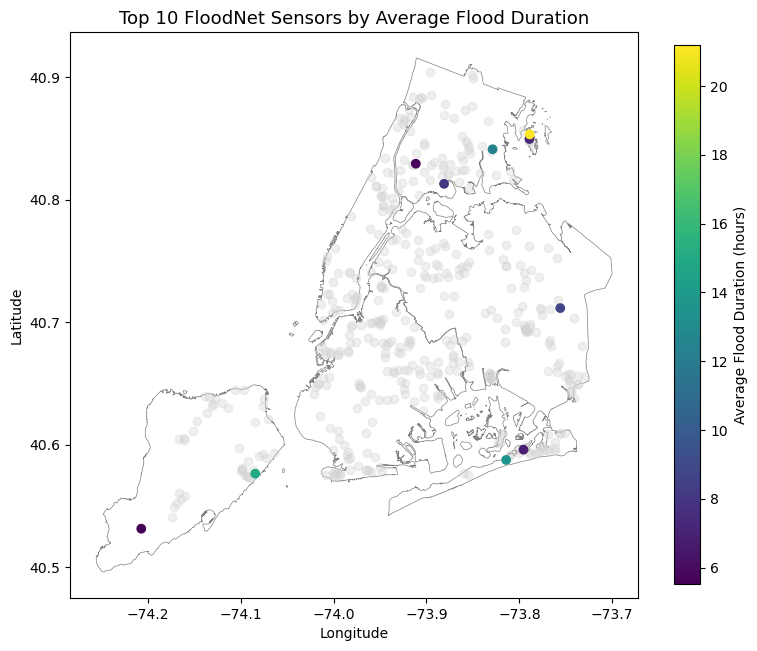

In [33]:
value_col = "average_duration_hrs"
title = "Top 10 FloodNet Sensors by Average Flood Duration"
label = "Average Flood Duration (hours)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 4.2 Top 10 Sensors by Average Flood Duration for Events Exceeding 12 inches

In [34]:
sensor_flood_summary = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        COUNT(sensor_id) AS flood_events,
        MAX(max_depth_inches) AS max_depth_inches,
        SUM(duration_mins) AS duration_mins,
        ROUND(SUM(duration_mins) / COUNT(sensor_id) / 60.0, 2) AS average_duration_hrs
    FROM merged_df
    WHERE max_depth_inches >= 12
    GROUP BY ALL
""")

sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY average_duration_hrs DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        flood_events,
        max_depth_inches,
        duration_mins,
        average_duration_hrs
    FROM sensor_flood_summary
    ORDER BY average_duration_hrs DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,flood_events,max_depth_inches,duration_mins,average_duration_hrs
i64,str,str,str,str,str,i64,f64,f64,f64
1,"""Q-beach-72nd-st-almeda-ave-1a5…","""Q - Beach 72nd St/Almeda Ave""","""Beach 72nd Street""","""Queens""","""Yes""",2,21.5,1001.94,8.35
2,"""Q-davenport-ct-1-07zks0""","""Q - Davenport Ct 1""","""Davenport Court""","""Queens""","""Yes""",19,40.87,8112.75,7.12
3,"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",1,17.68,420.97,7.02
4,"""Q-davenport-ct-2-07znk0""","""Q - Davenport Ct 2""","""Davenport Court""","""Queens""","""Yes""",1,16.14,416.91,6.95
5,"""Q-russell-st-2-07zt40""","""Q - Russell St 2""","""Russell Street""","""Queens""","""Yes""",4,31.77,1522.94,6.35
6,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""","""Ditmars Street""","""Bronx""","""Yes""",11,34.65,3919.82,5.94
7,"""BK-malcolm-x-blvd-fulton-st-2m…","""BK - Fulton St/ Malcom X Blvd""","""Fulton Street""","""Brooklyn""","""No""",1,15.63,328.97,5.48
8,"""BK-9th-st-smith-st-0etvg0""","""BK - 9th St/Smith St""","""9th Street""","""Brooklyn""","""No""",2,27.76,632.56,5.27
9,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""","""Russell Street""","""Queens""","""Yes""",11,31.34,3374.29,5.11


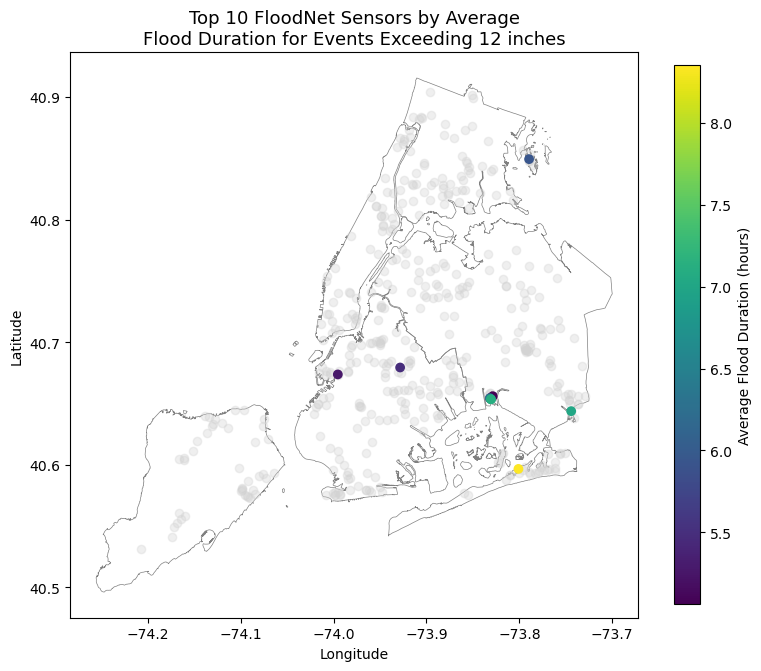

In [35]:
value_col = "average_duration_hrs"
title = "Top 10 FloodNet Sensors by Average\nFlood Duration for Events Exceeding 12 inches"
label = "Average Flood Duration (hours)"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

# 5) Duration of Flood Events by Number of Days Sensor was Deployed
Total flood duration alone favors sensors that have been deployed longer. Dividing by days deployed isolates the flood burden independent of deployment length, making a sensor installed last year directly comparable to one that has been active for five years. This answers the question: on average, how many hours per month is this location flooded?

## Normalize Flood Duration Total Minutes by Sensor Days Active

In [36]:
deployment_days = duckdb.sql("""
    SELECT
        sensor_id,
        date_diff('day', date_installed, current_date()) AS days_deployed
    FROM metadata_df
""")

flood_events = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        MAX(max_depth_inches) AS max_depth_inches,
        SUM(duration_mins) AS duration_mins,
        SUM(duration_above_12_inches_mins) AS duration_above_12_inches_mins
    FROM merged_df
    GROUP BY ALL
""")

flood_events = duckdb.sql("""
    SELECT
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        days_deployed,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
        ROUND((duration_mins / 60.0) / (days_deployed / 30.0), 2) AS average_hours_per_month
    FROM flood_events
    JOIN deployment_days USING (sensor_id)
""")

## 5.1 Top 10 Tidally Influenced Sensors by Total Flood Duration per Month

In [37]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY average_hours_per_month DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
        average_hours_per_month
    FROM flood_events
    WHERE tidally_influenced = 'Yes'
    ORDER BY average_hours_per_month DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,max_depth_inches,duration_mins,duration_above_12_inches_mins,average_hours_per_month
i64,str,str,str,str,str,f64,f64,f64,f64
1,"""BX-ditmars-st-hunter-ave-1kwrk…","""BX - Ditmars St/Hunter Ave 2""","""Ditmars Street""","""Bronx""","""Yes""",34.65,54524.18,1828.02,28.76
2,"""Q-beach-84-st-0me680""","""Q - Beach 84 St""","""Beach 84th Street""","""Queens""","""Yes""",38.19,70884.89,5088.26,21.89
3,"""Q-beach-84th-st-beach-channel-…","""Q - Beach 84 St (2)""","""Beach 84th Street""","""Queens""","""Yes""",20.67,7962.7,293.04,19.91
4,"""SI-quincy-ave-iona-st-1deh00""","""SI - Quincy Ave/Iona St""","""Quincy Avenue, Comanche Avenue""","""Staten Island""","""Yes""",5.59,33934.3,0.0,15.51
5,"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",19.76,11242.24,819.75,9.63
6,"""Q-russell-st-1-07zqc0""","""Q - Russell St 1""","""Russell Street""","""Queens""","""Yes""",31.34,27460.3,687.37,7.23
7,"""Q-brookville-blvd-rockaway-blv…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",17.68,7812.83,106.4,6.69
8,"""BX-cross-st-minnieford-ave-1kw…","""BX - Cross St/Minnieford Ave""","""Minnieford Avenue""","""Bronx""","""Yes""",2.52,11437.37,0.0,6.03
9,"""Q-brookville-blvd-149th-ave-3-…","""Q - Brookville Blvd/ Snake Rd …","""Brookville Boulevard""","""Queens""","""Yes""",13.94,6861.23,26.58,5.87


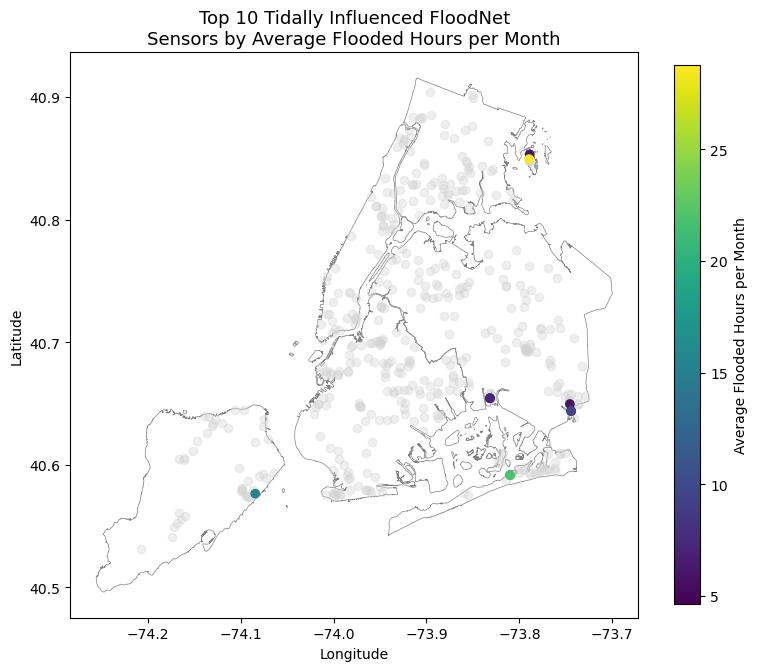

In [38]:
value_col = "average_hours_per_month"
title = "Top 10 Tidally Influenced FloodNet\nSensors by Average Flooded Hours per Month"
label = "Average Flooded Hours per Month"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

## 5.2 Top 10 Non-Tidally Influenced Sensors by Total Flood Duration per Month

In [39]:
sql = """
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY average_hours_per_month DESC
        ) AS sensor_rank,
        sensor_id,
        sensor_name,
        street_name,
        borough,
        tidally_influenced,
        days_deployed,
        max_depth_inches,
        duration_mins,
        duration_above_12_inches_mins,
        average_hours_per_month
    FROM flood_events
    WHERE tidally_influenced = 'No'
    ORDER BY average_hours_per_month DESC
    LIMIT 10
"""

ranked_df = duckdb.sql(sql).pl()

ranked_df

sensor_rank,sensor_id,sensor_name,street_name,borough,tidally_influenced,days_deployed,max_depth_inches,duration_mins,duration_above_12_inches_mins,average_hours_per_month
i64,str,str,str,str,str,i64,f64,f64,f64,f64
1,"""Q-beach-90th-st-rockaway-freew…","""Q - Beach 90th St/ Rockaway Fw…","""Beach 90th Street""","""Queens""","""No""",44,5.71,818.71,0.0,9.3
2,"""BX-w-234th-st-tibbett-ave-2cak…","""BX - Tibbett Ave/W 234th St""","""Tibbett Avenue""","""Bronx""","""No""",416,1.5,6207.38,0.0,7.46
3,"""BX-webster-ave-e-166th-st-2151…","""BX - Webster Ave/E 166th St""","""Webster Avenue""","""Bronx""","""No""",633,11.54,6424.14,0.0,5.07
4,"""Q-beach-59th-st-beach-channel-…","""Q - Beach Chn Dr/ Beach 59th S…","""Beach Channel Drive""","""Queens""","""No""",44,4.72,311.22,0.0,3.54
5,"""Q-204th-st-100th-ave-2msf80""","""Q - 204th St/ 100th Ave""","""204th Street""","""Queens""","""No""",212,23.35,1048.02,31.11,2.47
6,"""Q-155th-ave-79th-st-215zzc""","""Q - 155th Ave/79th St""","""79th Street""","""Queens""","""No""",632,8.11,2135.27,0.0,1.69
7,"""BK-e-92nd-st-avenue-j-2nick0""","""BK - E92nd St/ Ave J""","""East 92nd Street""","""Brooklyn""","""No""",198,1.34,661.36,0.0,1.67
8,"""Q-160th-ave-101st-st-2vfj80""","""Q - 101st St/160th Ave""","""101st Street""","""Queens""","""No""",44,2.68,137.98,0.0,1.57
9,"""BK-hoyt-st-5th-st-007sk0""","""BK - Hoyt St/5th St""","""Hoyt Street""","""Brooklyn""","""No""",2050,10.35,6360.65,0.0,1.55


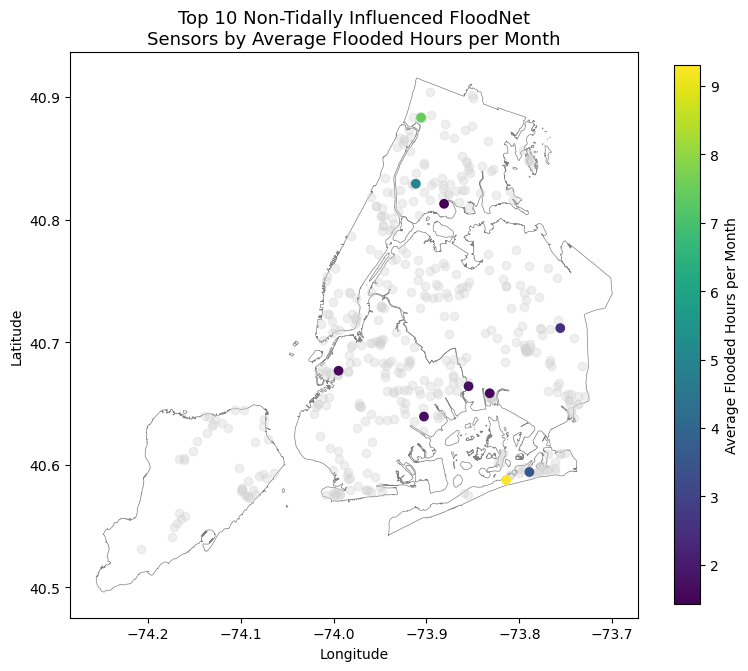

In [40]:
value_col = "average_hours_per_month"
title = "Top 10 Non-Tidally Influenced FloodNet\nSensors by Average Flooded Hours per Month"
label = "Average Flooded Hours per Month"

fig, ax = plot_ranked_sensors(
    ranked_df=ranked_df,
    metadata_gdf=metadata_gdf,
    boro_gdf=boro_gdf,
    value_col=value_col,
    title=title,
    label=label
)

# 6) Quickest Time to X Inches
Bonus: This metric is explored in greater depth in the next notebook on flood profiles.

In [41]:
def time_to_threshold(
    df,
    threshold_inches: float,
    top_n: int = 10,
    ts_sec_col="flood_profile_time_secs",
    ts_in_col="flood_profile_depth_inches",
    max_col="max_depth_inches",
    name_col="sensor_name",
    start_col="flood_start_time_est",
    end_col="flood_end_time_est",
):
    """
    Rank flood events by how quickly water depth reached a given threshold.

    For each eligible event, the function parses the raw time series,
    detects the first moment depth crosses threshold_inches using linear
    interpolation between readings, and computes the elapsed time and
    rise rate from flood onset to that crossing. Events are returned
    sorted by fastest crossing time.

    Parameters
    ----------
    df : pl.DataFrame or pd.DataFrame
        Flood events table containing time series and metadata columns.
        Converted to Polars internally if passed as pandas.
    threshold_inches : float
        Depth threshold in inches to detect (e.g. 12.0 for one foot).
    top_n : int, optional
        Number of fastest events to return. Default is 10.
    ts_sec_col : str, optional
        Column containing the raw time series of elapsed seconds.
        Values may be stored as stringified lists. Default is
        "flood_profile_time_secs".
    ts_in_col : str, optional
        Column containing the raw time series of depth readings in inches.
        Values may be stored as stringified lists. Default is
        "flood_profile_depth_inches".
    max_col : str, optional
        Column for maximum flood depth, used to filter eligible events.
        Default is "max_depth_inches".
    name_col : str, optional
        Column for sensor name. Default is "sensor_name".
    start_col : str, optional
        Column for flood event start time. Default is "flood_start_time_est".
    end_col : str, optional
        Column for flood event end time. Default is "flood_end_time_est".

    Returns
    -------
    pl.DataFrame
        One row per qualifying event, sorted by time_to_thresh_sec ascending,
        with the following columns:

        - name : str — sensor name
        - depth_max_inches : float — maximum depth reached during the event
        - start : datetime — flood event start time
        - end : datetime — flood event end time
        - threshold_inches : float — threshold passed to the function
        - time_to_thresh_sec : float — seconds from flood onset to threshold crossing
        - time_to_thresh_minutes : float — same, expressed in minutes
        - rate_to_thresh_in_per_min : float — average rise rate in inches per minute
        - x_values : list[float] — normalized elapsed seconds for the full time series
        - y_values : list[float] — depth readings in inches for the full time series

        Returns an empty pl.DataFrame if no events qualify or no crossings
        are detected.

    Notes
    -----
    Depth values below zero are clamped to zero before crossing detection.
    Time is normalized to zero at flood onset (first reading) per event.
    Crossing time is linearly interpolated between the last sub-threshold
    reading and the first reading at or above the threshold, so results
    are sensitive to sensor reporting frequency. Events with gaps or coarse
    intervals in the rising limb should be interpreted with caution.
    """

    if not isinstance(df, pl.DataFrame):
        df = pl.from_pandas(df)

    if df.is_empty():
        return pl.DataFrame()

    df = df.with_row_index("event_id")

    # Parse list columns
    df = df.with_columns([
        pl.col(ts_sec_col).map_elements(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x,
            return_dtype=pl.List(pl.Float64),
        ).alias("sec"),

        pl.col(ts_in_col).map_elements(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x,
            return_dtype=pl.List(pl.Float64),
        ).alias("depth"),
    ])

    # Filter eligible events
    df = df.filter(
        pl.col("sec").is_not_null()
        & pl.col("depth").is_not_null()
        & (pl.col(max_col) >= threshold_inches)
    )

    if df.is_empty():
        return pl.DataFrame()

    # Explode time series
    long = (
        df.select(
            "event_id",
            name_col,
            start_col,
            end_col,
            max_col,
            "sec",
            "depth",
        )
        .explode(["sec", "depth"])
        .with_columns([
            pl.col("sec").cast(pl.Float64),
            pl.col("depth").cast(pl.Float64),
        ])
        .drop_nulls(["sec", "depth"])
    )

    # Normalize time and clamp depth
    long = (
        long
        .with_columns(
            (pl.col("sec") - pl.first("sec").over("event_id")).alias("rel_sec")
        )
        .with_columns(
            pl.when(pl.col("depth") < 0)
            .then(0.0)
            .otherwise(pl.col("depth"))
            .alias("depth")
        )
        .sort(["event_id", "rel_sec"])
    )

    # store full time series
    series_data = (
        long
        .group_by("event_id")
        .agg([
            pl.col("rel_sec").implode().alias("x_values"),
            pl.col("depth").implode().alias("y_values"),
        ])
    )

    # add previous point for interpolation
    long = long.with_columns([
        pl.col("depth").shift(1).over("event_id").alias("prev_depth"),
        pl.col("rel_sec").shift(1).over("event_id").alias("prev_sec"),
        pl.first("depth").over("event_id").alias("start_depth"),
    ])

    # detect crossings
    crossings = long.filter(
        (pl.col("prev_depth") < threshold_inches) &
        (pl.col("depth") >= threshold_inches)
    )

    # interpolate crossing time
    crossings = crossings.with_columns(
        (
            pl.col("prev_sec")
            + (threshold_inches - pl.col("prev_depth"))
            / (pl.col("depth") - pl.col("prev_depth"))
            * (pl.col("rel_sec") - pl.col("prev_sec"))
        ).alias("time_to_thresh_sec")
    )

    # collapse to one row per event
    crossings = (
        crossings
        .group_by("event_id")
        .agg([
            pl.first("time_to_thresh_sec"),
            pl.first("start_depth"),
            pl.first(name_col).alias("name"),
            pl.first(start_col).alias("start"),
            pl.first(end_col).alias("end"),
            pl.first(max_col).alias("depth_max_inches"),
        ])
    )

    if crossings.is_empty():
        return pl.DataFrame()

    crossings = crossings.join(series_data, on="event_id", how="left")

    crossings = crossings.with_columns([
        pl.lit(threshold_inches).alias("threshold_inches"),
        pl.col("time_to_thresh_sec").round(2),
        (pl.col("time_to_thresh_sec") / 60).round(2).alias("time_to_thresh_minutes"),
        (
            (threshold_inches - pl.col("start_depth"))
            / (pl.col("time_to_thresh_sec") / 60)
        ).round(2).alias("rate_to_thresh_in_per_min"),
    ])

    return (
            crossings.sort("time_to_thresh_sec")
            .head(top_n)
            .with_columns(
                (pl.int_range(1, pl.len() + 1)).alias("rank")
            )
            .select([
                "rank",
                "name",
                "start",
                "end",
                "depth_max_inches",
                "threshold_inches",
                "time_to_thresh_sec",
                "time_to_thresh_minutes",
                "rate_to_thresh_in_per_min",
                "x_values",
                "y_values",
            ])
        )

## 6.1 Quickest Time to 12 Inches

In [42]:
threshold_inches = 12

time_to_threshold(
    df=merged_df,
    threshold_inches=threshold_inches
)

rank,name,start,end,depth_max_inches,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
i64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,i32,f64,f64,f64,list[f64],list[f64]
1,"""BK - Carroll St/4th Av""",2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,31.3,12,136.93,2.28,5.26,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
2,"""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,35.94,12,175.25,2.92,4.11,"[0.0, 63.0, … 7751.0]","[0.0, 1.22, … 0.0]"
3,"""BK - Carroll St/4th Av""",2021-09-01 21:27:16 EDT,2021-09-01 23:11:26 EDT,35.59,12,209.05,3.48,3.44,"[0.0, 312.0, … 6250.0]","[0.0, 17.91, … 0.0]"
4,"""Q - 204th St/ 100th Ave""",2025-10-30 16:04:44 EDT,2025-10-30 16:47:45 EDT,23.35,12,234.44,3.91,3.07,"[0.0, 60.0, … 2581.0]","[0.0, 0.98, … 0.0]"
5,"""BK - Greene Ave / Grand Ave""",2025-10-30 15:00:01 EDT,2025-10-30 16:02:01 EDT,17.6,12,299.87,5.0,2.4,"[0.0, 180.0, … 3720.0]","[0.0, 6.1, … 0.0]"
6,"""SI - Catherine Ct/Jewett Ave""",2025-07-31 15:40:39 EDT,2025-07-31 16:28:39 EDT,21.34,12,385.49,6.42,1.87,"[0.0, 60.0, … 2880.0]","[0.0, 3.35, … 0.0]"
7,"""BK - Carroll St/4th Av""",2021-08-22 00:05:05 EDT,2021-08-22 00:51:45 EDT,26.85,12,411.51,6.86,1.75,"[0.0, 311.0, … 2800.0]","[0.0, 8.82, … 0.0]"
8,"""Q - Liberty Ave/ 183rd St""",2025-10-30 15:58:49 EDT,2025-10-30 16:45:48 EDT,19.96,12,427.09,7.12,1.69,"[0.0, 120.0, … 2819.0]","[0.0, 1.26, … 0.0]"
9,"""BK - Carroll St/4th Av""",2021-08-21 21:19:06 EDT,2021-08-21 22:21:20 EDT,28.62,12,515.28,8.59,1.4,"[0.0, 311.0, … 3734.0]","[0.0, 5.04, … 0.0]"


## 6.2 Quickest Time to 24 Inches

In [43]:
threshold_inches = 24

time_to_threshold(
    df=merged_df,
    threshold_inches=threshold_inches, 
)

rank,name,start,end,depth_max_inches,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
i64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,i32,f64,f64,f64,list[f64],list[f64]
1,"""BK - Carroll St/4th Av""",2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,31.3,24,309.13,5.15,4.66,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
2,"""BK - Carroll St/4th Av""",2021-09-01 21:27:16 EDT,2021-09-01 23:11:26 EDT,35.59,24,479.61,7.99,3.0,"[0.0, 312.0, … 6250.0]","[0.0, 17.91, … 0.0]"
3,"""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,35.94,24,619.74,10.33,2.32,"[0.0, 63.0, … 7751.0]","[0.0, 1.22, … 0.0]"
4,"""BK - Carroll St/4th Av""",2021-08-22 00:05:05 EDT,2021-08-22 00:51:45 EDT,26.85,24,889.0,14.82,1.62,"[0.0, 311.0, … 2800.0]","[0.0, 8.82, … 0.0]"
5,"""BK - Carroll St/4th Av""",2021-08-21 21:19:06 EDT,2021-08-21 22:21:20 EDT,28.62,24,1135.04,18.92,1.27,"[0.0, 311.0, … 3734.0]","[0.0, 5.04, … 0.0]"
6,"""BK - 9th St/Smith St""",2023-09-29 07:54:23 EDT,2023-09-29 13:25:16 EDT,25.35,24,1922.5,32.04,0.75,"[0.0, 63.0, … 19853.0]","[0.0, 3.07, … 0.51]"
7,"""BK - Wallabout St/Throop Ave""",2023-09-29 08:05:49 EDT,2023-09-29 11:03:49 EDT,25.08,24,2372.0,39.53,0.61,"[0.0, 63.0, … 10680.0]","[0.0, 1.14, … 0.0]"
8,"""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,40.87,24,2381.93,39.7,0.6,"[0.0, 63.0, … 39898.0]","[0.0, 0.79, … 0.0]"
9,"""Q - Davenport Ct 1""",2024-03-10 07:44:49 EDT,2024-03-10 15:32:08 EDT,26.06,24,3687.58,61.46,0.39,"[0.0, 126.0, … 28039.0]","[0.0, 0.59, … 0.0]"


## 6.3 Quickest Time to 12 Inches for Tidal vs. Non Tidal Sensors

In [44]:
threshold_inches = 12

# tidally influenced sensors
tidal_df = merged_df.filter(pl.col("tidally_influenced") == 'Yes')

time_to_threshold(
    df=tidal_df,
    threshold_inches=threshold_inches
)

rank,name,start,end,depth_max_inches,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
i64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,i32,f64,f64,f64,list[f64],list[f64]
1,"""Q - Beach 43rd St""",2022-12-23 06:07:36 EST,2022-12-23 09:57:30 EST,23.43,12,1074.15,17.9,0.67,"[0.0, 252.0, … 13795.0]","[0.0, 4.06, … 0.0]"
2,"""Q - 1st St/104th St""",2024-03-10 07:57:07 EDT,2024-03-10 13:01:30 EDT,16.65,12,1078.71,17.98,0.67,"[0.0, 64.0, … 18264.0]","[0.0, 0.63, … 0.0]"
3,"""Q - Beach 43rd St""",2024-01-13 09:33:00 EST,2024-01-13 12:16:18 EST,18.46,12,1249.11,20.82,0.58,"[0.0, 189.0, … 9798.0]","[0.0, 4.72, … 0.0]"
4,"""Q - Russell St 2""",2022-12-23 05:12:13 EST,2022-12-23 11:34:35 EST,31.77,12,1320.57,22.01,0.55,"[0.0, 63.0, … 22943.0]","[0.0, 0.59, … 0.0]"
5,"""Q - Davenport Ct 1""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST,40.87,12,1486.19,24.77,0.48,"[0.0, 63.0, … 39898.0]","[0.0, 0.79, … 0.0]"
6,"""Q - Russell St 1""",2022-12-23 05:10:48 EST,2022-12-23 11:04:16 EST,31.34,12,1520.35,25.34,0.47,"[0.0, 303.0, … 21208.0]","[0.0, 1.97, … 0.0]"
7,"""Q - 1st St/104th St""",2024-04-04 03:00:17 EDT,2024-04-04 08:12:06 EDT,13.7,12,1533.49,25.56,0.47,"[0.0, 63.0, … 18709.0]","[0.0, 0.51, … 0.0]"
8,"""Q - Russell St 1""",2026-04-18 20:49:29 EDT,2026-04-19 01:06:29 EDT,14.65,12,1632.1,27.2,0.44,"[0.0, 60.0, … 15420.0]","[0.0, 0.91, … 0.0]"
9,"""Q - Russell St 1""",2024-03-10 07:35:18 EDT,2024-03-10 12:29:27 EDT,17.09,12,1700.85,28.35,0.42,"[0.0, 63.0, … 17649.0]","[0.0, 1.1, … 0.0]"


In [45]:
threshold_inches = 12

# non-tidal sensors
non_tidal_df = merged_df.filter(pl.col("tidally_influenced") == 'No')

time_to_threshold(
    df=non_tidal_df,
    threshold_inches=threshold_inches
)

rank,name,start,end,depth_max_inches,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
i64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",f64,i32,f64,f64,f64,list[f64],list[f64]
1,"""BK - Carroll St/4th Av""",2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,31.3,12,136.93,2.28,5.26,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
2,"""BK - Carroll St/4th Av""",2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,35.94,12,175.25,2.92,4.11,"[0.0, 63.0, … 7751.0]","[0.0, 1.22, … 0.0]"
3,"""BK - Carroll St/4th Av""",2021-09-01 21:27:16 EDT,2021-09-01 23:11:26 EDT,35.59,12,209.05,3.48,3.44,"[0.0, 312.0, … 6250.0]","[0.0, 17.91, … 0.0]"
4,"""Q - 204th St/ 100th Ave""",2025-10-30 16:04:44 EDT,2025-10-30 16:47:45 EDT,23.35,12,234.44,3.91,3.07,"[0.0, 60.0, … 2581.0]","[0.0, 0.98, … 0.0]"
5,"""BK - Greene Ave / Grand Ave""",2025-10-30 15:00:01 EDT,2025-10-30 16:02:01 EDT,17.6,12,299.87,5.0,2.4,"[0.0, 180.0, … 3720.0]","[0.0, 6.1, … 0.0]"
6,"""SI - Catherine Ct/Jewett Ave""",2025-07-31 15:40:39 EDT,2025-07-31 16:28:39 EDT,21.34,12,385.49,6.42,1.87,"[0.0, 60.0, … 2880.0]","[0.0, 3.35, … 0.0]"
7,"""BK - Carroll St/4th Av""",2021-08-22 00:05:05 EDT,2021-08-22 00:51:45 EDT,26.85,12,411.51,6.86,1.75,"[0.0, 311.0, … 2800.0]","[0.0, 8.82, … 0.0]"
8,"""Q - Liberty Ave/ 183rd St""",2025-10-30 15:58:49 EDT,2025-10-30 16:45:48 EDT,19.96,12,427.09,7.12,1.69,"[0.0, 120.0, … 2819.0]","[0.0, 1.26, … 0.0]"
9,"""BK - Carroll St/4th Av""",2021-08-21 21:19:06 EDT,2021-08-21 22:21:20 EDT,28.62,12,515.28,8.59,1.4,"[0.0, 311.0, … 3734.0]","[0.0, 5.04, … 0.0]"
